In [2]:
# Jupyter start cell (minimal)
from detection_runner import get_project_root, run_socket_listener

PROJECT_ROOT = get_project_root()  # or pass explicit_root="/Users/.../EE475-Smart-Fridge-Manager"
print("PROJECT_ROOT:", PROJECT_ROOT)

run_socket_listener(project_root=PROJECT_ROOT)

PROJECT_ROOT: /Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager
[DetectionRunner] Listening on /tmp/fridge_bus.sock
[DetectionRunner] Project root: /Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager
[DetectionRunner] Ready. Waiting for session_id...
[DetectionRunner] Listening...
[DetectionRunner] Listening...

[DetectionRunner] Received session_id: test_multi_put
[DetectionRunner] Processing session: test_multi_put
[DetectionRunner] Waiting for session directory: /Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager/data/sessions/session_test_multi_put
[DetectionRunner] Session directory found.
[DetectionRunner] Found vision file candidate: /Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager/data/sessions/session_test_multi_put/vision.json
[DetectionRunner] vision.json validated successfully.
[DetectionRunner] Using vision file: /Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager/data/sessions/session_test_multi_put/vis

   id               session_id            event_time_utc item_name     status  confidence  track_id
0   1  session_20260224_150000  2026-02-24T15:00:02.000Z     apple  IN_FRIDGE        0.85         7
1   2  session_20260224_160000  2026-02-24T16:00:02.000Z     apple  IN_FRIDGE        0.89         1
2   3  session_20260224_160000  2026-02-24T16:00:04.500Z    banana  IN_FRIDGE        0.88         2
3   4  session_20260224_160000  2026-02-24T16:00:07.000Z    orange  IN_FRIDGE        0.88         3


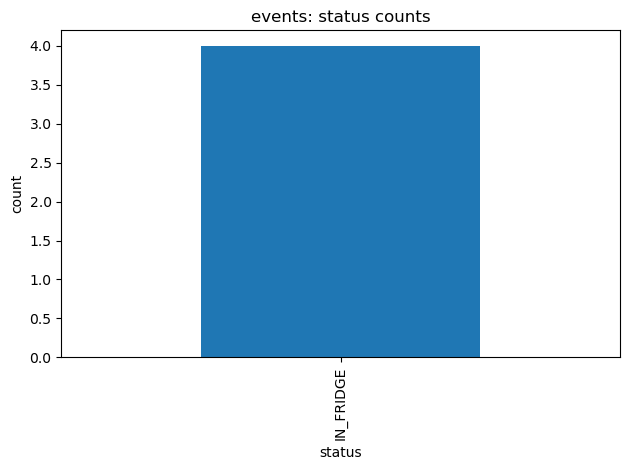

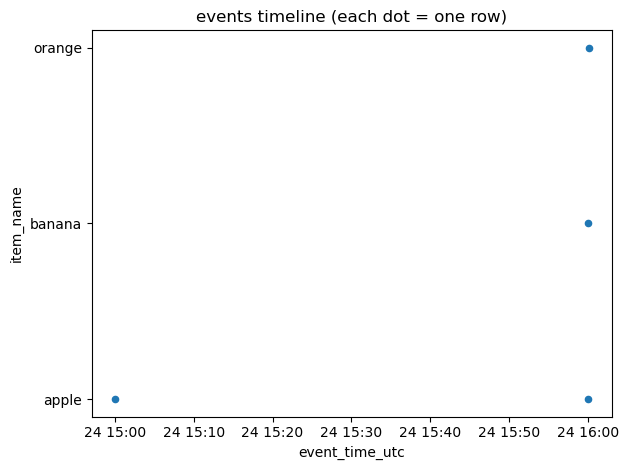


Inventory-like pivot (count of rows by item_name and status/action):
status     IN_FRIDGE
item_name           
apple              2
banana             1
orange             1


In [9]:
#!/usr/bin/env python3
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "/Users/liluoqi/Documents/Luoqi_github/EE475-Smart-Fridge-Manager/data/db/fridge.db"

def load_events(db_path: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    try:
        # 读取 events 表（如果列不同也能兼容：只要表存在）
        df = pd.read_sql_query("SELECT * FROM events ORDER BY event_time_utc ASC, id ASC;", conn)
    finally:
        conn.close()
    return df

def main():
    df = load_events(DB_PATH)

    if df.empty:
        print("events table is empty.")
        return

    # ---- 打印表格（前 200 行，避免刷屏）----
    with pd.option_context("display.max_rows", 200, "display.max_columns", 50, "display.width", 180):
        print(df)

    # ---- 基本清洗：解析时间（如果列存在）----
    if "event_time_utc" in df.columns:
        df["event_time_utc"] = pd.to_datetime(df["event_time_utc"], errors="coerce", utc=True)

    # ---- 1) 状态分布柱状图（status 或 action 兼容）----
    status_col = "status" if "status" in df.columns else ("action" if "action" in df.columns else None)
    if status_col:
        counts = df[status_col].fillna("NULL").value_counts()

        plt.figure()
        counts.plot(kind="bar")
        plt.title(f"events: {status_col} counts")
        plt.xlabel(status_col)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()
    else:
        print("No 'status' or 'action' column found; skip status distribution plot.")

    # ---- 2) 时间轴散点（每条事件一条点，按 item_name 分组）----
    if "event_time_utc" in df.columns and "item_name" in df.columns:
        # 只画时间可解析的行
        dft = df.dropna(subset=["event_time_utc"]).copy()
        if not dft.empty:
            # 给 item_name 做一个 y 轴编码
            items = sorted(dft["item_name"].astype(str).unique().tolist())
            item_to_y = {name: i for i, name in enumerate(items)}
            dft["_y"] = dft["item_name"].astype(str).map(item_to_y)

            plt.figure()
            plt.scatter(dft["event_time_utc"], dft["_y"], s=20)
            plt.yticks(range(len(items)), items)
            plt.title("events timeline (each dot = one row)")
            plt.xlabel("event_time_utc")
            plt.ylabel("item_name")
            plt.tight_layout()
            plt.show()
        else:
            print("No parsable timestamps; skip timeline plot.")
    else:
        print("Missing 'event_time_utc' or 'item_name'; skip timeline plot.")

    # ---- 3) 可选：按 item_name + status 的透视表（很适合看库存）----
    if "item_name" in df.columns and status_col:
        pivot = (
            df.pivot_table(index="item_name", columns=status_col, values="id", aggfunc="count", fill_value=0)
            .sort_index()
        )
        print("\nInventory-like pivot (count of rows by item_name and status/action):")
        print(pivot)

if __name__ == "__main__":
    main()